In [58]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from cooltools.lib import plotting
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
import seaborn as sns
import pandas as pd

from functools import reduce

from scipy.optimize import curve_fit
from sklearn.mixture import GaussianMixture
from scipy.stats import mannwhitneyu


In [59]:
import pybedtools as pbt

In [60]:
basedir = os.getcwd()
print(basedir)

%cd /home/varshini/uc_analyses/
import calc_insulation
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

/home/varshini/LoopCall_Analysis_Scripts
/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [61]:
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 14})

In [62]:
phases = ['Phase1_', 'Phase2_dedup', 'Phase3_dedup']
res = 2000
ins_res = 2000

uc_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'
uc_filenames = [os.path.join(uc_path, f"Sankaran_{p}merged.250.mcool") for p in phases]
uc_coolers = [utils.get_clr(clr_name, res) for clr_name in uc_filenames]

In [63]:
basedir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/boundaries/'
insulation_filenames = [os.path.join(basedir, f"{p}_microc_insulation_{ins_res}bp.tsv") for p in phases]
merged_insulation_filename = 'merged_boundary_strengths.tsv'

In [64]:
savedir = '/mnt/md0/varshini/Analysis/Blood/figs_v2/supp2'

In [65]:
def merge_boundaries(insulation_files, merge_method='outer'):
    og_cols = insulation_files[0].columns
    ins = []
    for j in range(len(insulation_files)):
        ins.append(insulation_files[j].rename(columns={c: c+f'_{j+1}' for c in insulation_files[j].columns[4:]}))
    #print(ins)
    
    outer_merged_boundaries = reduce(lambda left,right: pd.merge(left,right,on=['chrom', 'start','end', 'region'], how=merge_method), ins)
    #print(outer_merged_boundaries)
    
    # for every window, keep any interval where any phase has a boundary at that window
    # save as window-specific files
    
    windows = set([num for num in [col.split('_')[-1] for col in og_cols] if num.isdigit()])
    window_df = {}
    
    for w in windows:
        # subset merged df on columns 5+ for containing the numeric w 
        cols = [col for col in outer_merged_boundaries.columns if w in col]

        cols_to_keep = outer_merged_boundaries.columns[:5].to_list()
        cols_to_keep.extend(cols)
        #print(cols_to_keep)
        sub_df = outer_merged_boundaries[cols_to_keep]
        #print(sub_df)
        
        # keep only where any column containing boundary_strength_{w} is True 
        boundary_cols = [col for col in cols if f'is_boundary_{w}' in col]
        sub_df = sub_df[sub_df[boundary_cols].any(axis=1)]
        
        print(sub_df)
        # save the window df and append it to the dict as well? just append for now, or add save method
        window_df[w] = sub_df
    
    return window_df



In [66]:
insulation_files = [pd.read_csv(i, sep='\t') for i in insulation_filenames]

In [67]:
window_df = merge_boundaries(insulation_files)

        chrom      start        end  region  is_bad_bin_1  \
451      chr1     902000     904000  chr1_p         False   
488      chr1     976000     978000  chr1_p         False   
489      chr1     978000     980000  chr1_p         False   
558      chr1    1116000    1118000  chr1_p         False   
653      chr1    1306000    1308000  chr1_p         False   
...       ...        ...        ...     ...           ...   
1515066  chrX  155092000  155094000  chrX_q         False   
1515067  chrX  155094000  155096000  chrX_q         False   
1515120  chrX  155200000  155202000  chrX_q          True   
1515370  chrX  155700000  155702000  chrX_q          True   
1515446  chrX  155852000  155854000  chrX_q          True   

         log2_insulation_score_100000_1  n_valid_pixels_100000_1  \
451                            0.571029                   1947.0   
488                            0.391642                   2497.0   
489                            0.388130                   2447.

        chrom      start        end  region  is_bad_bin_1  \
433      chr1     866000     868000  chr1_p         False   
434      chr1     868000     870000  chr1_p         False   
488      chr1     976000     978000  chr1_p         False   
489      chr1     978000     980000  chr1_p         False   
538      chr1    1076000    1078000  chr1_p          True   
...       ...        ...        ...     ...           ...   
1515426  chrX  155812000  155814000  chrX_q          True   
1515446  chrX  155852000  155854000  chrX_q          True   
1515471  chrX  155902000  155904000  chrX_q          True   
1515487  chrX  155934000  155936000  chrX_q         False   
1515497  chrX  155954000  155956000  chrX_q         False   

         log2_insulation_score_50000_1  n_valid_pixels_50000_1  \
433                           0.302410                   522.0   
434                           0.294336                   522.0   
488                           0.266139                   622.0   
489

In [68]:
w=20_000
test_ins = window_df[str(w)]

In [69]:
print(len(test_ins[(test_ins[f'is_boundary_{w}_1']==True)
                            |(test_ins[f'is_boundary_{w}_2']==True)
                            |(test_ins[f'is_boundary_{w}_3']==True)]))

print(len(test_ins))

83820
83820


3008
3536
477
4578
4084
1622


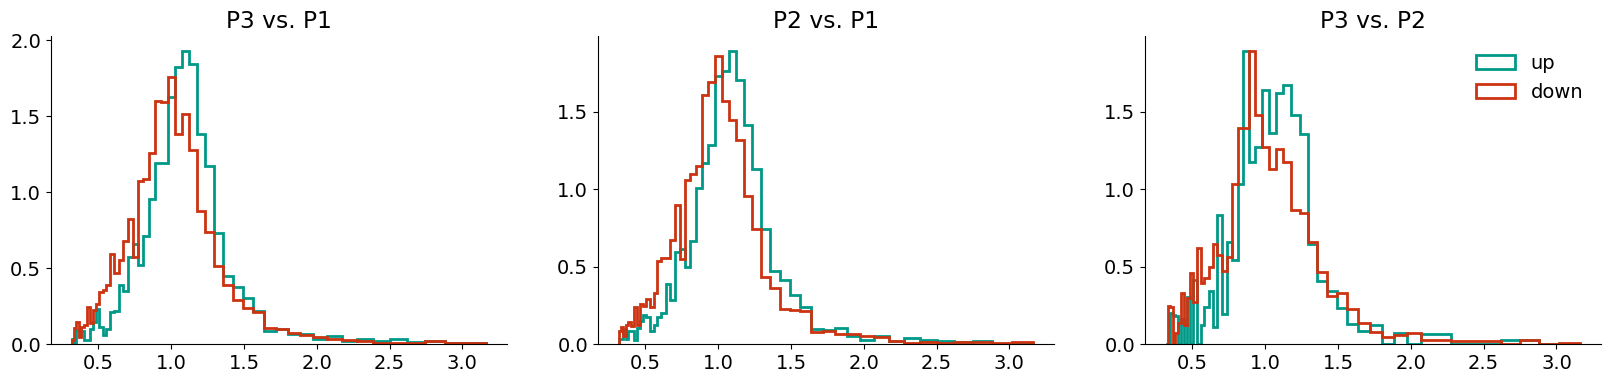

In [73]:
# use each of the up/down files and merge with the merged_boundary_strengths to get the BS
all_vals = []
datadir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/boundaries'
for i, reg in enumerate(["up", "down"]):
    vals = pd.DataFrame(columns=["P3_vs_P1", "P3_vs_P2", "P2_vs_P1"])
    for p in ["P3_vs_P1", "P3_vs_P2", "P2_vs_P1"]:
        fname = os.path.join(datadir, f"{p}_{reg}_ins_bulked.bed")
        # these are the boundary intervals that are intersected with the DEG TSSs
        bs = pd.read_csv(fname, sep="\t")
        bs = bs.iloc[:, :3]
        bs.columns = ['chrom','start','end']
        # now, find the boundary strength of these boundaries 
        bs_merged = bs.merge(test_ins, how='inner', on=['chrom','start','end'])
        if p=="31":
            FC = bs_merged[f'boundary_strength_{w}_3'].divide(bs_merged[f'boundary_strength_{w}_1'])
        elif p=="21":
            FC = bs_merged[f'boundary_strength_{w}_2'].divide(bs_merged[f'boundary_strength_{w}_1'])
        else:
            FC = bs_merged[f'boundary_strength_{w}_3'].divide(bs_merged[f'boundary_strength_{w}_2'])
        print(len(FC))
        vals[p] = FC
    all_vals.append(vals)

f, axs = plt.subplots(1, 3, figsize=(20,4))
colors = ['#009988', '#CC3311']

for i, reg in enumerate(["up", "down"]):
    hist_args = {
            "bins":np.logspace(-0.5, 0.5, 50), 
             "label":reg, 
             "alpha":1,
             "histtype":'step',
             "color": colors[i],
             "linewidth":2,
             "density":True
            }
    
    axs[0].hist(all_vals[i]["P3_vs_P1"], **hist_args)
    axs[0].set_title('P3 vs. P1')
    axs[1].hist(all_vals[i]["P3_vs_P2"], **hist_args)
    axs[1].set_title('P2 vs. P1')
    axs[2].hist(all_vals[i]["P2_vs_P1"], **hist_args)
    axs[2].set_title('P3 vs. P2')
plt.legend(frameon=False)
plt.savefig(os.path.join(savedir,'ge_boundaries_multiome.svg'), dpi=300)
plt.show()

In [71]:
mannwhitneyu(all_vals[0]["P3_vs_P1"].dropna().values, all_vals[1]["P3_vs_P1"].dropna().values)

MannwhitneyuResult(statistic=2882400.5, pvalue=1.0729202296470145e-22)

1064
910
365
1097
717
402


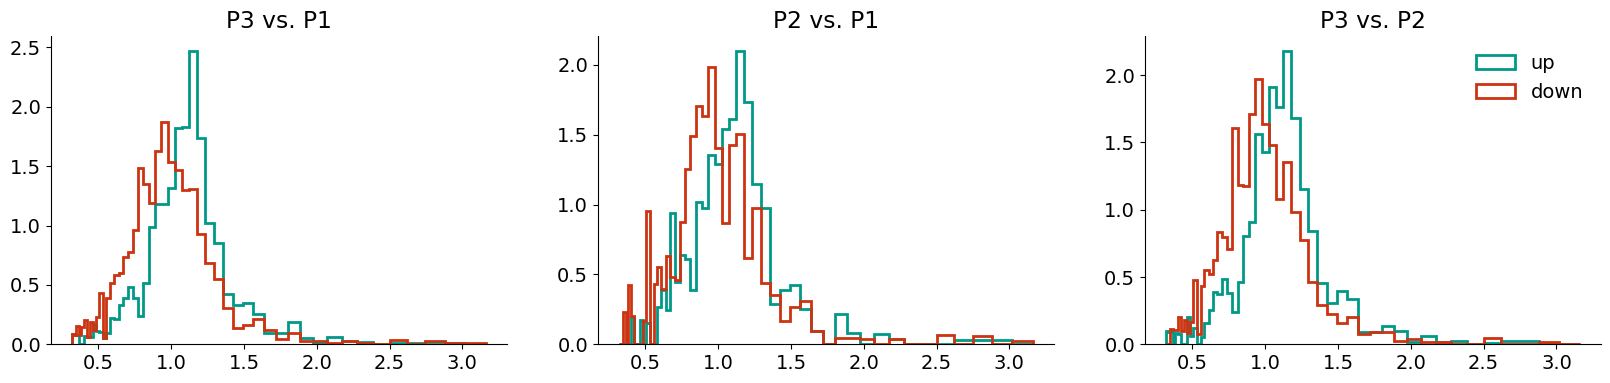

In [74]:
# use each of the up/down files and merge with the merged_boundary_strengths to get the BS
all_vals = []
datadir = '/mnt/md0/varshini/Analysis/Blood/GeneExp'
for i, reg in enumerate(["up", "down"]):
    vals = pd.DataFrame(columns=["p31", "p32", "p21"])
    for p in ["p31", "p32", "p21"]:
        fname = os.path.join(datadir, f"{p}_{reg}_ins_v3.bed")
        # these are the boundary intervals that are intersected with the DEG TSSs
        bs = pd.read_csv(fname, sep="\t")
        bs = bs.iloc[:, :3]
        bs.columns = ['chrom','start','end']
        # now, find the boundary strength of these boundaries 
        bs_merged = bs.merge(test_ins, how='left', on=['chrom','start','end'])
        #print(bs_merged)
        if p=="31":
            FC = bs_merged[f'boundary_strength_{w}_3'].divide(bs_merged[f'boundary_strength_{w}_1'])
        elif p=="21":
            FC = bs_merged[f'boundary_strength_{w}_2'].divide(bs_merged[f'boundary_strength_{w}_1'])
        else:
            FC = bs_merged[f'boundary_strength_{w}_3'].divide(bs_merged[f'boundary_strength_{w}_2'])
        print(len(FC))
        vals[p] = FC
    all_vals.append(vals)

f, axs = plt.subplots(1, 3, figsize=(20,4))
colors = ['#009988', '#CC3311']

for i, reg in enumerate(["up", "down"]):
    hist_args = {
            "bins":np.logspace(-0.5, 0.5, 50), 
             "label":reg, 
             "alpha":1,
             "histtype":'step',
             "color": colors[i],
             "linewidth":2,
             "density":True
            }
    
    axs[0].hist(all_vals[i]["p31"], **hist_args)
    axs[0].set_title('P3 vs. P1')
    axs[1].hist(all_vals[i]["p21"], **hist_args)
    axs[1].set_title('P2 vs. P1')
    axs[2].hist(all_vals[i]["p32"], **hist_args)
    axs[2].set_title('P3 vs. P2')
plt.legend(frameon=False)
plt.savefig(os.path.join(savedir,'ge_boundaries_cellrep.svg'), dpi=300)
plt.show()

In [28]:
mannwhitneyu(all_vals[0]["p31"].dropna().values, all_vals[1]["p31"].dropna().values)

MannwhitneyuResult(statistic=414698.0, pvalue=3.857222785982828e-22)

## Gained and lost boundaries by annotation class

In [29]:
test_ins_clean = test_ins[['chrom','start','end',f'log2_insulation_score_{w}_1',f'log2_insulation_score_{w}_2',f'log2_insulation_score_{w}_3']]
test_ins_clean.dropna(inplace=True)

/tmp/ipykernel_1179134/1810839905.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_ins_clean.dropna(inplace=True)


In [31]:
w=20_000
test_ins = window_df[str(w)]

all_bounds_2kb_20kb = test_ins[(test_ins[f'is_boundary_{w}_1']==True)
                            |(test_ins[f'is_boundary_{w}_2']==True)
                            |(test_ins[f'is_boundary_{w}_3']==True)]

gained_13 = test_ins[test_ins.is_boundary_20000_3 & ~test_ins.is_boundary_20000_1]
lost_12 = test_ins[~test_ins.is_boundary_20000_2 & test_ins.is_boundary_20000_1]





### save boundaries for the motif analysis
all_bounds_2kb_20kb.to_csv(os.path.join(basedir, 'all_bounds_2kb_20kb.bed'), header=None, sep='\t', index=False)
lost_12.to_csv(os.path.join(basedir, 'lost_p12_boundary_2kb_20kb.bed'), header=None, sep='\t', index=False)
gained_13.to_csv(os.path.join(basedir, 'gained_p13_boundary_2kb_20kb.bed'), header=None, sep='\t', index=False)

In [27]:
w=50_000
test_ins = window_df[str(w)]

all_bounds_2kb_50kb = test_ins[(test_ins[f'is_boundary_{w}_1']==True)
                            |(test_ins[f'is_boundary_{w}_2']==True)
                            |(test_ins[f'is_boundary_{w}_3']==True)]


gained_13 = test_ins[test_ins.is_boundary_50000_3 & ~test_ins.is_boundary_50000_1]
lost_12 = test_ins[~test_ins.is_boundary_50000_2 & test_ins.is_boundary_50000_1]


### save boundaries

all_bounds_2kb_50kb.to_csv(os.path.join(basedir, 'all_bounds_2kb_50kb.bed'), header=None, sep='\t', index=False)
lost_12.to_csv(os.path.join(basedir, 'lost_p12_boundary_2kb_50kb.bed'), header=None, sep='\t', index=False)
gained_13.to_csv(os.path.join(basedir, 'gained_p13_boundary_2kb_50kb.bed'), header=None, sep='\t', index=False)

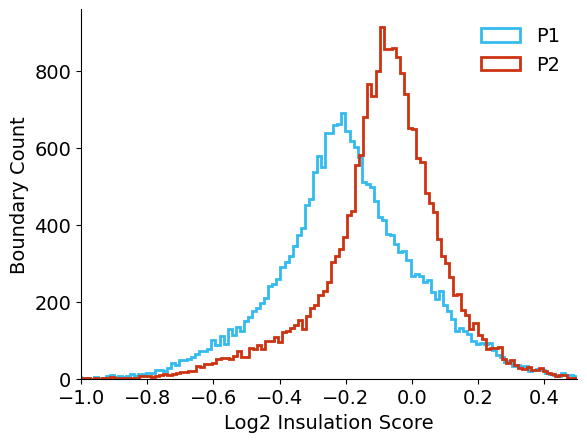

In [32]:
plt.hist(lost_12[f'log2_insulation_score_{w}_1'], bins=200, color='#33BBEE',alpha=1, histtype='step', linewidth=2, label='P1')
plt.hist(lost_12[f'log2_insulation_score_{w}_2'], bins=200, color='#CC3311',alpha=1, histtype='step', linewidth=2, label='P2')
plt.legend(frameon=False)
plt.xlim(-1, 0.5)
plt.xlabel('Log2 Insulation Score')
plt.ylabel('Boundary Count')
#plt.savefig(os.path.join(savedir, "lost_12_ins_v2.svg"))

plt.show()

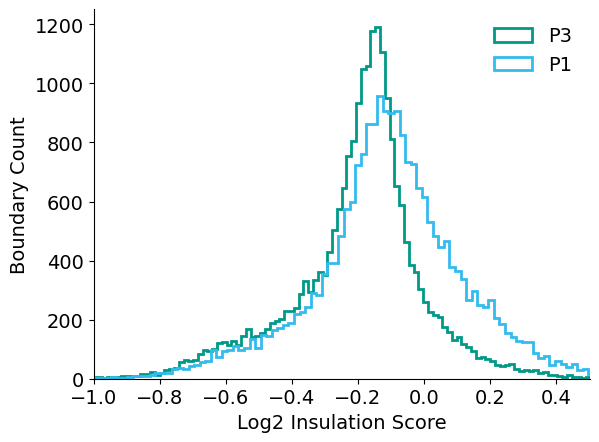

In [33]:
plt.hist(gained_13[f'log2_insulation_score_{w}_3'], bins=200, color='#009988',alpha=1, label='P3', linewidth=2,histtype='step')
plt.hist(gained_13[f'log2_insulation_score_{w}_1'], bins=200, color='#33BBEE',alpha=1, label='P1', linewidth=2,histtype='step')
plt.legend(frameon=False)
plt.ylabel('Boundary Count')
plt.xlim(-1, 0.5)

plt.xlabel('Log2 Insulation Score')
#plt.savefig(os.path.join(savedir, "gained_13_ins_v2.svg"))
plt.show()

In [47]:
### intersecting with promoters and CTCF ###
w=20_000
test_ins = window_df[str(w)]

trackdir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/'
prom_fname = '/mnt/md0/varshini/Gene_Annotations/hg38.refGene.tss_strand.bed'
prom_fname_access = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/gene_sets_expr/promoters_accessible_all.bed'


In [48]:
os.listdir(trackdir)

['erythroid_tracks',
 'merged_CTCF_P123_strand.bed',
 'merged_enhancers_500bp.bed',
 'track_classifications',
 'merged_CTCF_P123.bed']

In [49]:
x = pbt.BedTool.from_dataframe(test_ins)

In [50]:
def plot_insulation_scores(df, w):
    plt.scatter(df[f'log2_insulation_score_{w}_1'], df[f'log2_insulation_score_{w}_2'],  alpha=0.1)
    plt.plot(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50), '--')
    plt.show()

    plt.scatter(df[f'log2_insulation_score_{w}_2'], df[f'log2_insulation_score_{w}_3'], alpha=0.1)
    plt.plot(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50), '--')
    plt.show()
    
    plt.scatter(df[f'log2_insulation_score_{w}_1'], df[f'log2_insulation_score_{w}_3'], alpha=0.1)
    plt.plot(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50), '--')
    plt.show()

def plot_boundary_strengths(df, w):
    
    df[f'boundary_strength_{w}_1'] = pd.to_numeric(df[f'boundary_strength_{w}_1'], errors='coerce')
    df[f'boundary_strength_{w}_2'] = pd.to_numeric(df[f'boundary_strength_{w}_2'], errors='coerce')
    df[f'boundary_strength_{w}_3'] = pd.to_numeric(df[f'boundary_strength_{w}_3'], errors='coerce')

    plt.scatter(df[f'boundary_strength_{w}_1'], df[f'boundary_strength_{w}_2'],  alpha=0.1)
    plt.plot(np.linspace(0, 3, 50), np.linspace(0, 3, 50), '--', color='k')
    plt.show()

    plt.scatter(df[f'boundary_strength_{w}_2'], df[f'boundary_strength_{w}_3'], alpha=0.1)
    plt.plot(np.linspace(0, 3, 50), np.linspace(0, 3, 50), '--', color='k')
    plt.show()

    plt.scatter(df[f'boundary_strength_{w}_1'], df[f'boundary_strength_{w}_3'], alpha=0.1)
    plt.plot(np.linspace(0, 3, 50), np.linspace(0, 3, 50), '--', color='k')
    plt.show()

def plot_boundary_strengths_hist(df, w):
    plt.hist(pd.to_numeric(df[f'boundary_strength_{w}_1'], errors='coerce').dropna(), bins=200)
    plt.show()

    plt.hist(pd.to_numeric(df[f'boundary_strength_{w}_2'], errors='coerce').dropna(), bins=200)
    plt.show()

    plt.hist(pd.to_numeric(df[f'boundary_strength_{w}_3'], errors='coerce').dropna(), bins=200)
    plt.show()
    
def clean_df(df, w):
    df[f'boundary_strength_{w}_1'] = pd.to_numeric(df[f'boundary_strength_{w}_1'], errors='coerce')
    df[f'boundary_strength_{w}_2'] = pd.to_numeric(df[f'boundary_strength_{w}_2'], errors='coerce')
    df[f'boundary_strength_{w}_3'] = pd.to_numeric(df[f'boundary_strength_{w}_3'], errors='coerce')
    
    df[f'log2_insulation_score_{w}_1'] = pd.to_numeric(df[f'log2_insulation_score_{w}_1'], errors='coerce')
    df[f'log2_insulation_score_{w}_2'] = pd.to_numeric(df[f'log2_insulation_score_{w}_2'], errors='coerce')
    df[f'log2_insulation_score_{w}_3'] = pd.to_numeric(df[f'log2_insulation_score_{w}_3'], errors='coerce')
    
    return df

In [51]:
promoter_boundaries = x.intersect(prom_fname_access, u=True)
promoter_boundaries_df = promoter_boundaries.to_dataframe(header=None)
promoter_boundaries_df.columns = test_ins.columns

/home/varshini/microc_analyses/lib/python3.9/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 17 fields; you can supply custom names with the `names` kwarg
  warn(


In [52]:
promoter_boundaries_excl = promoter_boundaries.intersect(os.path.join(trackdir, 'merged_CTCF_P123_strand.bed'), v=True)
promoter_boundaries_excl_df = promoter_boundaries_excl.to_dataframe(header=None)
promoter_boundaries_excl_df.columns = test_ins.columns
promoter_boundaries_excl_df['fc'] = pd.to_numeric(promoter_boundaries_excl_df[f'boundary_strength_{w}_3'], errors='coerce').divide(pd.to_numeric(promoter_boundaries_excl_df[f'boundary_strength_{w}_1'], errors='coerce'))
#promoter_boundaries_excl_df = promoter_boundaries_excl_df[promoter_boundaries_excl_df[f'is_boundary_{w}_1']==True]


/home/varshini/microc_analyses/lib/python3.9/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 17 fields; you can supply custom names with the `names` kwarg
  warn(


In [53]:
ctcf_boundaries = x.intersect(os.path.join(trackdir, 'merged_CTCF_P123_strand.bed'), u=True)
ctcf_boundaries = ctcf_boundaries.intersect(prom_fname_access, v=True)
ctcf_boundaries_df = ctcf_boundaries.to_dataframe(header=None)
ctcf_boundaries_df.columns = test_ins.columns

/home/varshini/microc_analyses/lib/python3.9/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 17 fields; you can supply custom names with the `names` kwarg
  warn(


In [54]:
ctcf_boundaries_df_P1 = ctcf_boundaries_df[ctcf_boundaries_df[f'is_boundary_{w}_1']==True]
ctcf_boundaries_df_P1['fc'] = pd.to_numeric(ctcf_boundaries_df_P1[f'boundary_strength_{w}_3'], errors='coerce').divide(pd.to_numeric(ctcf_boundaries_df_P1[f'boundary_strength_{w}_1'], errors='coerce'))


/tmp/ipykernel_1179134/656395198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctcf_boundaries_df_P1['fc'] = pd.to_numeric(ctcf_boundaries_df_P1[f'boundary_strength_{w}_3'], errors='coerce').divide(pd.to_numeric(ctcf_boundaries_df_P1[f'boundary_strength_{w}_1'], errors='coerce'))


In [55]:
def boundary_sharing_phase(df, w):
    fig, ax = plt.subplots()

    # plot the number of bounds retained vs lost from p1-2, p2-3
    num_retained_p12 = len(df[(df[f'is_boundary_{w}_1']==True) & (df[f'is_boundary_{w}_2']==True)])
    num_lost_p12 = len(df[(df[f'is_boundary_{w}_1']==True) & (df[f'is_boundary_{w}_2']==False)])                   
    num_gained_p12 = len(df[(df[f'is_boundary_{w}_1']==False) & (df[f'is_boundary_{w}_2']==True)])  
                         
    num_retained_p23 = len(df[(df[f'is_boundary_{w}_2']==True) & (df[f'is_boundary_{w}_3']==True)])
    num_lost_p23 = len(df[(df[f'is_boundary_{w}_2']==True) & (df[f'is_boundary_{w}_3']==False)])
    num_gained_p23 = len(df[(df[f'is_boundary_{w}_2']==False) & (df[f'is_boundary_{w}_3']==True)])  
    
    num_retained_p13 = len(df[(df[f'is_boundary_{w}_1']==True) & (df[f'is_boundary_{w}_3']==True)])
    num_lost_p13 = len(df[(df[f'is_boundary_{w}_1']==True) & (df[f'is_boundary_{w}_3']==False)])
    num_gained_p13 = len(df[(df[f'is_boundary_{w}_1']==False) & (df[f'is_boundary_{w}_3']==True)])  
    
    p12 = np.array([num_retained_p12, num_lost_p12, num_gained_p12])
    p23 = np.array([num_retained_p23, num_lost_p23, num_gained_p23])                   
    p23 = np.array([num_retained_p13, num_lost_p13, num_gained_p13])         
    
    xlab = ['P1->2', 'P2->3']
    bottom = np.zeros(2)
    
    ax.bar(xlab, np.array([num_retained_p12, num_retained_p23]), label='retained',  bottom=bottom)
    bottom+=np.array([num_retained_p12, num_retained_p23])
    ax.bar(xlab, np.array([num_lost_p12, num_lost_p23]), label='lost',  bottom=bottom)
    bottom+=np.array([num_lost_p12, num_lost_p23])
    ax.bar(xlab, np.array([num_gained_p12, num_gained_p23]), label='gained',  bottom=bottom)
    
    plt.legend()
    plt.show()
                    
def bar_boundaries(df, w):
    fig, ax = plt.subplots()
    for i in range(1, 4):
        curr_len = len(df[df[f'is_boundary_{w}_{i}']==True])
        ax.bar(f'Phase {i}', curr_len)
        
    plt.show()

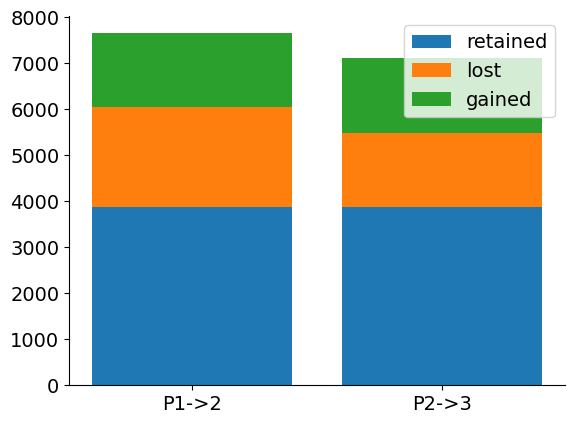

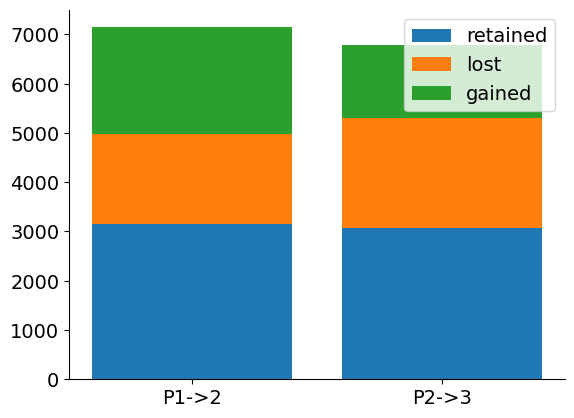

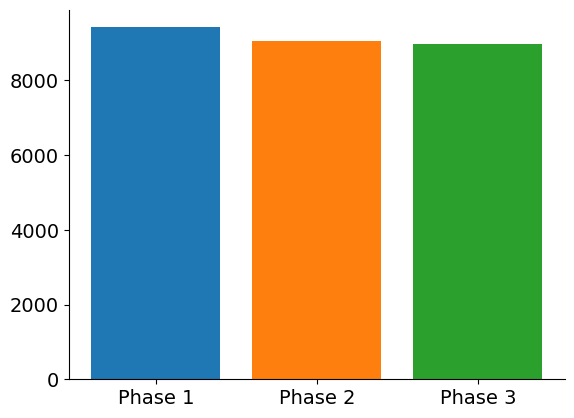

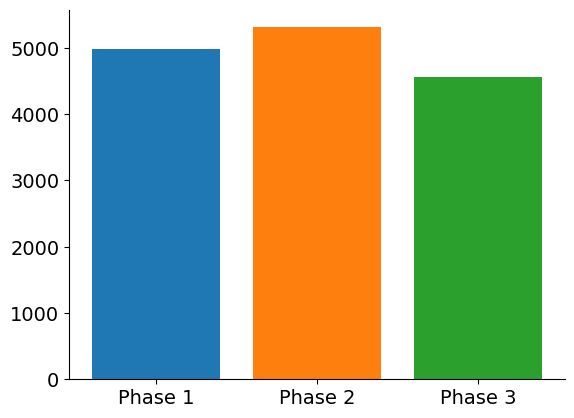

In [56]:
boundary_sharing_phase(promoter_boundaries_excl_df, w)
boundary_sharing_phase(ctcf_boundaries_df, w)


bar_boundaries(promoter_boundaries_df, w)
bar_boundaries(ctcf_boundaries_df, w)


In [57]:
print(len(promoter_boundaries_df[promoter_boundaries_df[f'is_boundary_{w}_1']==True]))
print(len(promoter_boundaries_df[promoter_boundaries_df[f'is_boundary_{w}_2']==True]))
print(len(promoter_boundaries_df[promoter_boundaries_df[f'is_boundary_{w}_3']==True]))

9425
9060
8973


In [67]:

print(ctcf_boundaries_df[f'log2_insulation_score_{w}_1'].mean())
print(ctcf_boundaries_df[f'log2_insulation_score_{w}_2'].mean())
print(ctcf_boundaries_df[f'log2_insulation_score_{w}_3'].mean())

-0.25487331929986734
-0.23239922882386105
-0.2443296684493614
